In [1]:
import torch
import torch.nn.functional as F
import os
import sys
from trainer.supervised_trainer.engine import trainer
project_root = '/public/home/zhangshikang/project/decouple_detr/DecoupleDETR/'
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)
from dataset import (build_dataset, build_loader)
from models import build_model
from util.config import ConfigDict
from util.distributed import init_distributed_mode

ModuleNotFoundError: No module named 'trainer'

In [2]:
cfg = ConfigDict.from_file('config/experiments/pannuke_supervised.yaml')
init_distributed_mode(cfg)
model_trainer = trainer(cfg,False)

NameError: name 'ConfigDict' is not defined

- defining the hooks 

In [ ]:
hook_output = {}
hook_input = {}
def get_attention_map(name):
    def hook(model, input, output):      
        hook_output[name] = output
        hook_input[name] = input
    return hook
model.decouple_decoder.inital_layer.cross_attn.sampling_offsets.register_forward_hook(get_attention_map('sample_offsets_0'))
model.decouple_decoder.register_forward_hook(get_attention_map('original_represent'))
for i in range(2):
    model.decouple_decoder.layers[i].cross_attn.sampling_offsets.register_forward_hook(get_attention_map(f'sampling_offsets_{i+1}'))

In [55]:
model = model.to('cuda')
imgs,targets = next(iter(test_loader))
imgs = imgs.to('cuda')
model.eval()
with torch.no_grad():
    outputs = model(imgs,targets)

In [41]:
instance = outputs['contrastive_logits'][7][:16]
anchor = outputs['contrastive_logits'][7][16:]

In [42]:
cos_instance_anchor = F.cosine_similarity(instance.unsqueeze(1),anchor.unsqueeze(0),dim=-1)

In [43]:
cos_instance = F.cosine_similarity(instance.unsqueeze(1),instance.unsqueeze(0),dim=-1)

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

In [45]:
cos = cos_instance_anchor.T.cpu().detach().clone().numpy()

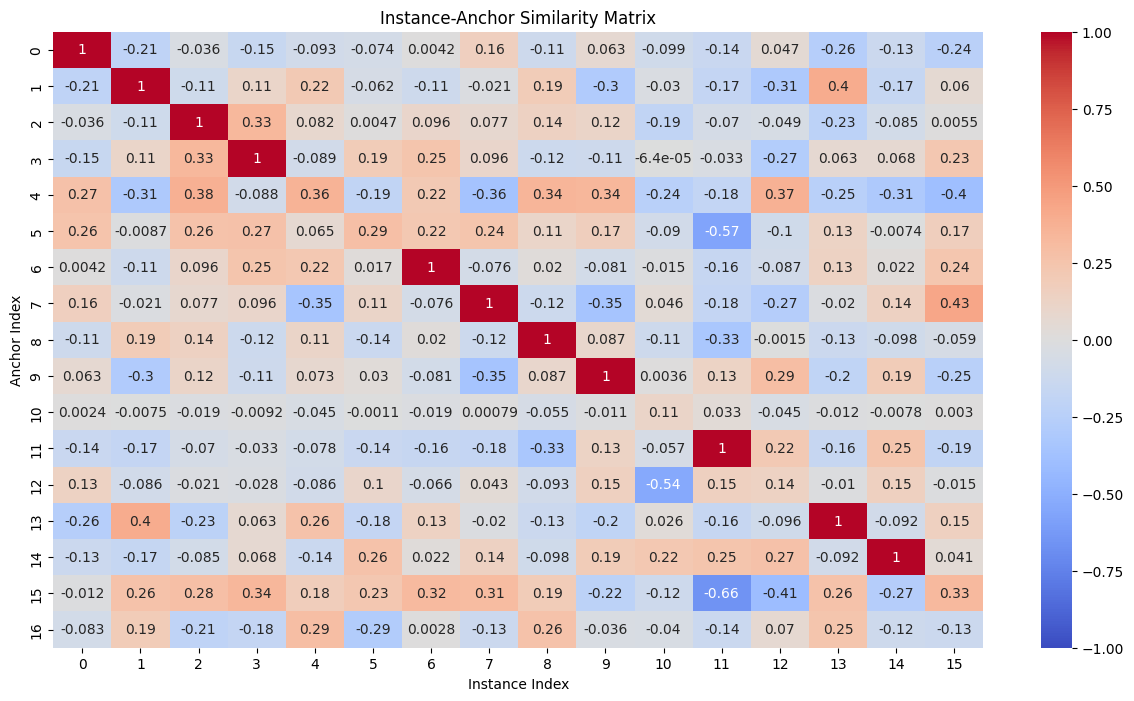

In [58]:
plt.figure(figsize=(15, 8))
sns.heatmap(cos, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Instance-Anchor Similarity Matrix')
plt.xlabel('Instance Index')
plt.ylabel('Anchor Index')
plt.show()

In [48]:
cos_instance = cos_instance.cpu().numpy()

In [60]:
targets[7]['labels']

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 2])

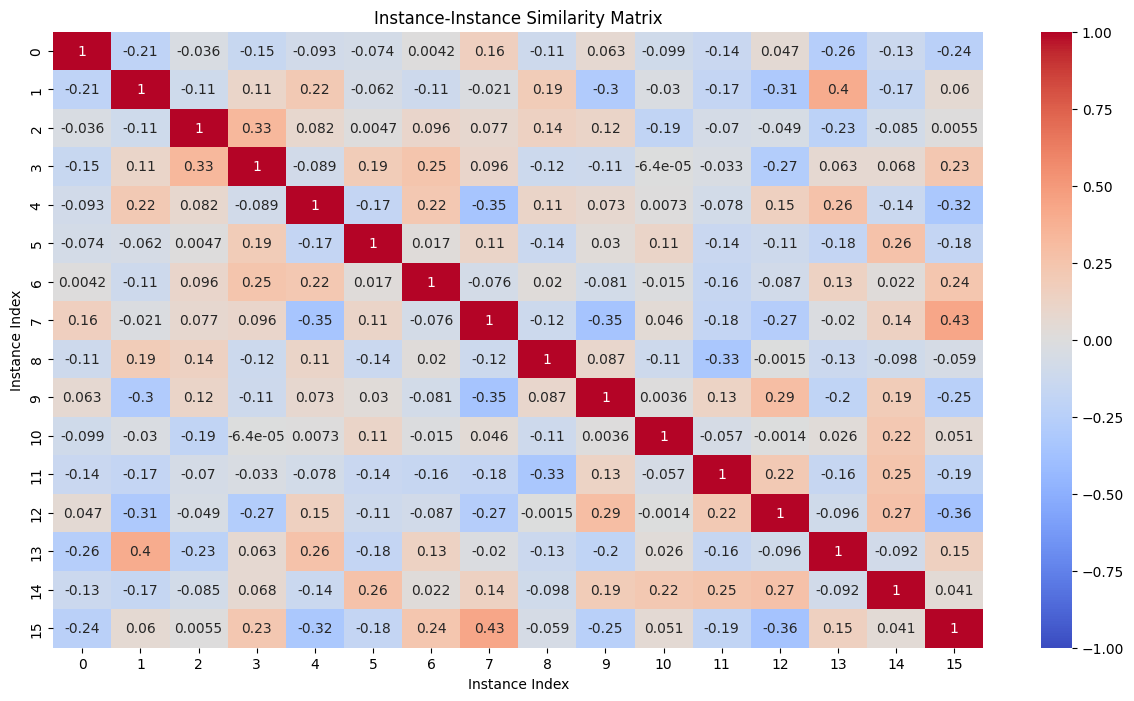

In [50]:
plt.figure(figsize=(15, 8))
sns.heatmap(cos_instance, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Instance-Instance Similarity Matrix')
plt.xlabel('Instance Index')
plt.ylabel('Instance Index')
plt.show()

In [51]:
hook_output = {}
hook_input = {}
def get_attention_map(name):
    def hook(model, input, output):      
        hook_output[name] = output
        hook_input[name] = input
    return hook

In [52]:
model.decouple_decoder.inital_layer.cross_attn.sampling_offsets.register_forward_hook(get_attention_map('sample_offsets_0'))
for i in range(2):
    model.decouple_decoder.layers[i].cross_attn.sampling_offsets.register_forward_hook(get_attention_map(f'sampling_offsets_{i+1}'))

In [65]:
hook_input

{'sample_offsets_0': (tensor([[[ 1.0173, -0.5670,  0.6036,  ...,  0.3976,  0.7690, -0.1277],
           [ 1.1007, -0.6956,  0.4454,  ...,  0.3311,  0.8317,  0.0496],
           [ 1.1171, -0.4243,  0.3674,  ...,  0.4926,  0.5448, -0.4767],
           ...,
           [ 1.0305, -0.3577,  0.5950,  ...,  0.3805,  0.6603, -0.2571],
           [ 1.2175, -0.3810, -0.0604,  ...,  0.6546,  0.7106, -0.3418],
           [ 1.1749, -1.8545,  0.6235,  ...,  0.2156,  0.6106, -0.1363]],
  
          [[ 1.1147, -0.3941,  0.1651,  ...,  0.7978,  0.5205, -0.7701],
           [ 1.1041, -0.6217,  0.4383,  ...,  0.2849,  0.8793,  0.1567],
           [ 1.0540, -0.5781,  0.5326,  ...,  0.3809,  0.7606, -0.1099],
           ...,
           [ 1.0209, -0.5913,  0.5811,  ...,  0.4539,  0.7159, -0.2478],
           [ 1.0988, -0.5812,  0.4120,  ...,  0.3516,  0.8446,  0.0501],
           [ 1.1749, -1.8545,  0.6235,  ...,  0.2156,  0.6106, -0.1363]],
  
          [[ 1.0661, -0.5554,  0.4823,  ...,  0.3301,  0.8906,  

In [66]:
hook_output['sample_offsets_0'].shape

torch.Size([8, 33, 256])

In [75]:
so_1 = hook_output['sample_offsets_0'].view(8, 33, 8, 4, 4, 2)
so_1 = so_1[0,:16,:,:,:,:]
boxes =targets[7]['boxes'].to(so_1.device)
# boxes = torch.cat(boxes,dim=0)
sp = F.tanh(so_1) * 0.5*boxes[:,None,None,None,2:]

In [77]:
sp.shape

torch.Size([16, 8, 4, 4, 2])

In [78]:
targets[7]

{'image_id': 7,
 'boxes': BoundingBoxes([[0.2070, 0.0586, 0.1367, 0.1133],
                [0.9492, 0.2109, 0.0938, 0.2188],
                [0.2930, 0.2812, 0.1445, 0.1641],
                [0.4336, 0.3398, 0.1250, 0.1680],
                [0.6953, 0.4258, 0.1445, 0.2734],
                [0.9336, 0.4336, 0.1211, 0.1328],
                [0.6211, 0.5859, 0.1328, 0.1797],
                [0.2227, 0.7148, 0.1094, 0.1445],
                [0.8984, 0.8945, 0.1719, 0.2031],
                [0.5977, 0.9453, 0.1445, 0.0977],
                [0.7031, 0.9844, 0.1172, 0.0234],
                [0.6289, 0.2188, 0.0703, 0.0859],
                [0.1641, 0.4844, 0.1719, 0.0859],
                [0.7500, 0.6445, 0.0938, 0.1953],
                [0.9414, 0.6836, 0.1094, 0.0898],
                [0.4375, 0.7266, 0.1016, 0.1602]], format=BoundingBoxFormat.CXCYWH, canvas_size=(256, 256), clamping_mode=soft),
 'labels': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 2])}

In [85]:
labels[0]

tensor(0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


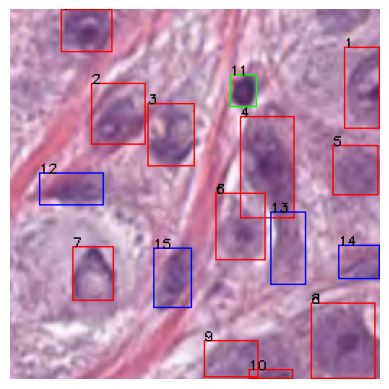

In [102]:
img = test_dataset.get_raw_image(7).numpy().transpose(1, 2, 0)
labels = targets[7]['labels']
boxes = targets[7]['boxes'].detach().cpu().numpy()
length = 16
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.3
font_thickness = 1
bg_color = (255, 255, 255) 
text_color = (0, 0, 0) 
for i in range(length):
    box = boxes[i]*256
    x1, y1 = int(box[0]-box[2]/2), int(box[1]-box[3]/2)
    x2, y2 = int(box[0]+box[2]/2), int(box[1]+box[3]/2)
    if labels[i].item() == 0:
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 1)
    elif labels[i].item() == 1:
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 1)
    else:
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 1)
    text = f'{i}'
    (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)
    text_x = x1
    text_y = y1
    # cv2.rectangle(
    #     img, 
    #     (int(x1), int(y1) - text_height - baseline - 5),  # 左上角
    #     (int(x1) + text_width, int(y1)),  # 右下角
    #     # bg_color, 
    #     # -1  # 填充矩形
    # )
    cv2.putText(img, text, (text_x, text_y), font, font_scale, text_color, font_thickness)
plt.axis('off')
plt.imshow(img, vmin=0, vmax=255)
    

In [ ]:
img = test_dataset.get_raw_image(0).numpy().transpose(1, 2, 0)
labels = targets[7]['labels']
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.3
font_thickness = 1
bg_color = (255, 255, 255) 
text_color = (0, 0, 0) 
anchor_index = 18
cos_matrix = F.cosine_similarity(instance.unsqueeze(1),instance.unsqueeze(0),dim=-1)[anchor_index]
length = 16
for i in range(length):
    box = boxes[i].detach().cpu().numpy()*256
    x1, y1 = int(box[0]-box[2]/2), int(box[1]-box[3]/2)
    x2, y2 = int(box[0]+box[2]/2), int(box[1]+box[3]/2)
    if i == anchor_index:
        cv2.rectangle(img, (int(x2),int(y2)), (int(x1),int(y1)), (0,0,255), 1)
    else:
        cv2.rectangle(img, (int(x2),int(y2)), (int(x1),int(y1)), (0,255,0), 1)
    text = f'{labels[i]}:{cos_matrix[i]:.2f}'
    (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)
    text_x = x1
    text_y = y1
    cv2.rectangle(
        img, 
        (int(x1), int(y1) - text_height - baseline - 5),  # 左上角
        (int(x1) + text_width, int(y1)),  # 右下角
        bg_color, 
        -1  # 填充矩形
    )
    cv2.putText(img, text, (text_x, text_y), font, font_scale, text_color, font_thickness)
    point = (box[:2] + sp[i].view(-1, 2).detach().cpu().numpy()*256).astype(int)
    atten_map = atten[0][i].view(-1).detach().cpu().numpy()
    for k,j in enumerate(point):
        if atten_map[k] > 0.1:
            cv2.circle(img, (j[0], j[1]), 1, (255,0,0), -1)
plt.imshow(img)

NameError: name 'sp' is not defined